# M1.Ex2: Model Experience vs Salary

name:Sarah Mohammed

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Step 1. Load the data

In [4]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv"

df = pd.read_csv(url)

df.head()

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
X = df[['Experience Years']]
y = df['Salary']

### Step 2.b print the type of each

In [6]:
print(f"X type: {type(X)}")
print(f"y type: {type(y)}")

X type: <class 'pandas.DataFrame'>
y type: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [7]:
print("Target: Numerical, Task: Regression")

Target: Numerical, Task: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (40, 1)
y shape: (40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

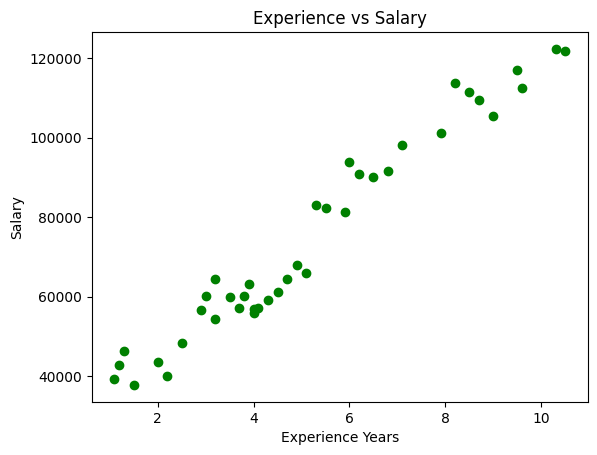

In [10]:
plt.scatter(X, y, color='green')
plt.title('Experience vs Salary')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [11]:
print("Relationship: Increasing")

Relationship: Increasing


### Step 7. Initialize a regression model

In [12]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 32
Testing set size: 8


### Step 9.a Train the model on the training set

In [14]:
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [15]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (Salary increase per year): {slope}")
print(f"Intercept (Starting salary): {intercept}")

Slope (Salary increase per year): 9408.03127250658
Intercept (Starting salary): 26716.250176145535


### Step 9.c how much salary does a person get with 2 years of experience?

In [16]:
prediction_2years = model.predict([[2]])
print(f"Salary for 2 years of experience: {prediction_2years[0]}")

Salary for 2 years of experience: 45532.3127211587


c:\Users\soso\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [17]:
six_months_increase = slope * 0.5
print(f"Salary increase for 6 months: {six_months_increase}")

Salary increase for 6 months: 4704.01563625329


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [18]:
print(f"Estimated starting salary (Zero experience): {intercept}")

Estimated starting salary (Zero experience): 26716.250176145535


### Step 10. Evaluate the model on the test set

In [19]:
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy (R^2): {accuracy}")

Model Accuracy (R^2): 0.9068577573647874


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [20]:
X_sample = X_test.head(3)
y_true = y_test.head(3)

y_pred = model.predict(X_sample)

results = pd.DataFrame({
    'Actual Salary': y_true.values,
    'Predicted Salary': y_pred
})
print(results)

   Actual Salary  Predicted Salary
0          61111      69052.390902
1          56957      64348.375266
2          55794      64348.375266


### Step 12. Plot the data and the regression line

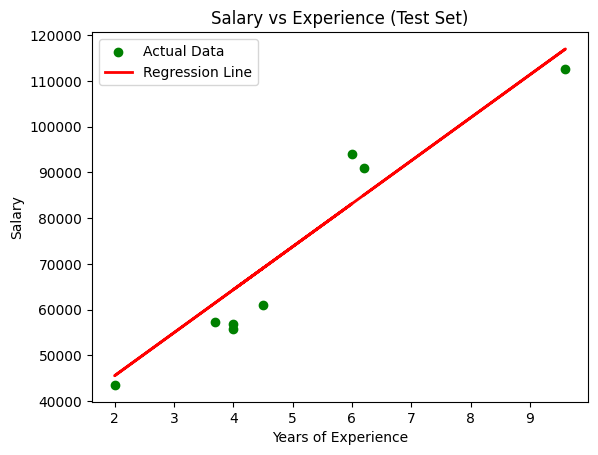

In [21]:
plt.scatter(X_test, y_test, color='green', label='Actual Data')

plt.plot(X_test, model.predict(X_test), color='red', linewidth=2, label='Regression Line')

plt.title('Salary vs Experience (Test Set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()